In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

### 프로젝트 셋팅

In [2]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final3_2.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [3]:
# 데이터를 읽어온다.
train_df = pd.read_parquet('pca_train27.parquet')
test_df = pd.read_parquet('pca_test27.parquet')

display(train_df)
display(test_df)

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p19,p20,p21,p22,p23,p24,p25,p26,p27,Segment
0,-2243.552933,73177.822751,-23307.067102,7561.747680,-3243.689945,4528.594709,-4408.328899,8369.204846,-6309.014641,1232.178495,...,-670.054714,1078.355402,1920.870547,2544.053619,1235.750939,-679.654072,-2314.977216,-2820.217356,3471.198333,D
1,-4123.593577,-18596.799844,-5281.553928,552.003971,2047.728562,2851.121296,-2005.535562,3877.903215,-889.924568,3031.998145,...,657.221496,1475.141165,863.926840,-1177.211648,2831.235120,-68.137893,-409.367207,-210.311572,692.184782,E
2,93844.494981,123215.256247,-21110.839100,-7111.076138,-5582.733393,13547.760971,-1048.762694,9425.227220,1943.737288,-143.578503,...,-2800.120608,1230.518402,-1406.511713,-2206.140597,1277.749684,738.283748,1992.859764,-471.409934,2129.448671,C
3,10648.448214,115700.176918,-21742.094573,11510.390672,-7770.532201,-7559.367421,-5333.651781,13026.736609,-76.952401,259.298011,...,-71.778393,949.211049,2950.268504,975.595853,801.520108,-9.139923,-968.875714,56.685869,3217.504543,D
4,-76132.442560,-2534.422667,-1881.492818,724.219680,-55.011442,-2366.802627,-931.083210,71.543290,-16.547834,-290.180408,...,-284.008621,-2322.540842,-2072.645932,634.432208,-1033.942702,473.094923,-216.472421,407.438128,868.839736,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,-70708.144660,-4606.543015,2805.802812,-7312.121123,-3526.939821,-4965.947914,220.135111,1057.678517,2360.636914,1934.651584,...,-775.194681,-1093.950869,-880.464696,-509.537637,-358.298234,6.232325,-456.213452,-150.847244,-202.958921,E
2399996,140275.356530,814.052457,-29512.108767,23504.905499,-9175.280457,5675.125393,16409.620662,2465.542079,-4928.311445,2604.849964,...,245.148039,-1467.533990,-3041.636512,-2123.278748,2089.569477,-2060.825006,-146.818560,-2142.007302,-1252.212106,D
2399997,17590.595793,3334.474385,5996.492939,645.269909,-4197.372200,1762.693541,-60.440877,2115.391058,-919.578172,2820.212880,...,-405.046693,302.598929,-458.846992,-558.545886,-1726.557745,966.842573,-1173.216523,508.343071,919.475442,C
2399998,-75089.653851,-3665.731945,-3620.020117,709.662982,42.502434,-1556.732214,-1652.830372,84.509015,-302.824774,-692.984227,...,3.779371,-234.113635,-94.101872,-461.100118,-253.046171,45.248177,-381.512640,-8.681741,9.269813,E


,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p18,p19,p20,p21,p22,p23,p24,p25,p26,p27
0,5449.770391,-15457.519040,7975.048602,-2971.418102,-1137.004767,4011.962178,11551.144025,3357.707117,-2924.619991,-1328.630772,...,192.708076,-2603.045310,6486.179111,5040.282733,884.032817,-776.952494,2111.313036,-694.188774,-1286.961085,306.843671
1,-39956.605754,26232.031298,1163.543109,-8719.802046,-6359.839502,-9991.102021,-4302.131559,15137.268711,10291.412366,815.171481,...,2076.203376,2799.656589,-765.383540,2007.854072,1813.109968,-817.880168,2123.054119,213.050147,1166.435590,1912.699923
2,91343.368173,20400.129674,49117.164568,18297.225678,-3701.289740,445.182612,-8089.748597,9430.604081,-8090.458230,-63.631268,...,-2300.244976,-2180.985710,1976.296387,1498.115258,617.151610,557.424181,281.863780,741.645539,1809.517677,1443.538363
3,-60622.721464,-2779.211139,172.147096,-1520.579234,494.335648,-2245.292748,-2498.491928,4213.196662,2446.223072,-925.403801,...,611.909126,677.146880,1175.953033,339.431785,63.668976,-470.056671,-770.600264,-332.992309,1118.849356,-54.599501
4,-48203.789429,188.499776,8676.875460,-8345.019526,-4152.234195,-8421.964779,-2943.931762,4537.336519,1748.248578,-1903.155041,...,538.235135,1567.426466,490.377157,422.267112,1492.421103,482.156591,1349.365467,38.372575,190.328715,518.087953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,-75126.065175,-3705.200634,-3607.179077,706.459174,88.174569,-1576.755827,-1673.193119,66.734157,-311.373311,-693.622316,...,-99.179096,52.185987,25.174890,-525.887342,-346.753069,-283.930403,81.819950,-374.758094,-8.492226,27.595341
599996,-69393.140789,-2960.239476,-1778.824783,-236.728825,-975.862235,-3279.293119,-1335.075258,1572.949261,733.136012,-850.853994,...,1104.853614,-301.709977,-972.853633,-1086.022765,239.215755,-739.975975,154.691256,-982.463430,309.586499,-990.804398
599997,-75112.821114,-3689.619067,-3601.622684,707.283464,73.604369,-1557.581357,-1663.292209,80.980196,-310.201058,-691.082182,...,-24.579710,64.067763,53.626928,-627.955001,-311.882147,-294.117050,93.183060,-326.612659,66.469509,-108.870756
599998,429765.434690,-147776.679200,-45333.927642,-79709.429139,-51300.598740,-19337.740212,4039.117750,2184.738303,42456.455268,14162.848870,...,-3638.910661,1245.666898,1028.243274,-1718.329770,3274.497209,1430.706916,-5689.597895,-9427.709388,257.810928,3771.296874


In [4]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p19,p20,p21,p22,p23,p24,p25,p26,p27,Segment
0,-2243.552933,73177.822751,-23307.067102,7561.747680,-3243.689945,4528.594709,-4408.328899,8369.204846,-6309.014641,1232.178495,...,-670.054714,1078.355402,1920.870547,2544.053619,1235.750939,-679.654072,-2314.977216,-2820.217356,3471.198333,D
1,-4123.593577,-18596.799844,-5281.553928,552.003971,2047.728562,2851.121296,-2005.535562,3877.903215,-889.924568,3031.998145,...,657.221496,1475.141165,863.926840,-1177.211648,2831.235120,-68.137893,-409.367207,-210.311572,692.184782,E
2,93844.494981,123215.256247,-21110.839100,-7111.076138,-5582.733393,13547.760971,-1048.762694,9425.227220,1943.737288,-143.578503,...,-2800.120608,1230.518402,-1406.511713,-2206.140597,1277.749684,738.283748,1992.859764,-471.409934,2129.448671,C
3,10648.448214,115700.176918,-21742.094573,11510.390672,-7770.532201,-7559.367421,-5333.651781,13026.736609,-76.952401,259.298011,...,-71.778393,949.211049,2950.268504,975.595853,801.520108,-9.139923,-968.875714,56.685869,3217.504543,D
4,-76132.442560,-2534.422667,-1881.492818,724.219680,-55.011442,-2366.802627,-931.083210,71.543290,-16.547834,-290.180408,...,-284.008621,-2322.540842,-2072.645932,634.432208,-1033.942702,473.094923,-216.472421,407.438128,868.839736,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,-75126.065175,-3705.200634,-3607.179077,706.459174,88.174569,-1576.755827,-1673.193119,66.734157,-311.373311,-693.622316,...,52.185987,25.174890,-525.887342,-346.753069,-283.930403,81.819950,-374.758094,-8.492226,27.595341,NaN
2999996,-69393.140789,-2960.239476,-1778.824783,-236.728825,-975.862235,-3279.293119,-1335.075258,1572.949261,733.136012,-850.853994,...,-301.709977,-972.853633,-1086.022765,239.215755,-739.975975,154.691256,-982.463430,309.586499,-990.804398,NaN
2999997,-75112.821114,-3689.619067,-3601.622684,707.283464,73.604369,-1557.581357,-1663.292209,80.980196,-310.201058,-691.082182,...,64.067763,53.626928,-627.955001,-311.882147,-294.117050,93.183060,-326.612659,66.469509,-108.870756,NaN
2999998,429765.434690,-147776.679200,-45333.927642,-79709.429139,-51300.598740,-19337.740212,4039.117750,2184.738303,42456.455268,14162.848870,...,1245.666898,1028.243274,-1718.329770,3274.497209,1430.706916,-5689.597895,-9427.709388,257.810928,3771.296874,NaN


In [5]:
# 결과 데이터는 제거한다.
all_df.drop('Segment', axis=1, inplace=True)
all_df

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p18,p19,p20,p21,p22,p23,p24,p25,p26,p27
0,-2243.552933,73177.822751,-23307.067102,7561.747680,-3243.689945,4528.594709,-4408.328899,8369.204846,-6309.014641,1232.178495,...,7041.455364,-670.054714,1078.355402,1920.870547,2544.053619,1235.750939,-679.654072,-2314.977216,-2820.217356,3471.198333
1,-4123.593577,-18596.799844,-5281.553928,552.003971,2047.728562,2851.121296,-2005.535562,3877.903215,-889.924568,3031.998145,...,673.134529,657.221496,1475.141165,863.926840,-1177.211648,2831.235120,-68.137893,-409.367207,-210.311572,692.184782
2,93844.494981,123215.256247,-21110.839100,-7111.076138,-5582.733393,13547.760971,-1048.762694,9425.227220,1943.737288,-143.578503,...,-747.349426,-2800.120608,1230.518402,-1406.511713,-2206.140597,1277.749684,738.283748,1992.859764,-471.409934,2129.448671
3,10648.448214,115700.176918,-21742.094573,11510.390672,-7770.532201,-7559.367421,-5333.651781,13026.736609,-76.952401,259.298011,...,5666.289339,-71.778393,949.211049,2950.268504,975.595853,801.520108,-9.139923,-968.875714,56.685869,3217.504543
4,-76132.442560,-2534.422667,-1881.492818,724.219680,-55.011442,-2366.802627,-931.083210,71.543290,-16.547834,-290.180408,...,-279.655391,-284.008621,-2322.540842,-2072.645932,634.432208,-1033.942702,473.094923,-216.472421,407.438128,868.839736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,-75126.065175,-3705.200634,-3607.179077,706.459174,88.174569,-1576.755827,-1673.193119,66.734157,-311.373311,-693.622316,...,-99.179096,52.185987,25.174890,-525.887342,-346.753069,-283.930403,81.819950,-374.758094,-8.492226,27.595341
2999996,-69393.140789,-2960.239476,-1778.824783,-236.728825,-975.862235,-3279.293119,-1335.075258,1572.949261,733.136012,-850.853994,...,1104.853614,-301.709977,-972.853633,-1086.022765,239.215755,-739.975975,154.691256,-982.463430,309.586499,-990.804398
2999997,-75112.821114,-3689.619067,-3601.622684,707.283464,73.604369,-1557.581357,-1663.292209,80.980196,-310.201058,-691.082182,...,-24.579710,64.067763,53.626928,-627.955001,-311.882147,-294.117050,93.183060,-326.612659,66.469509,-108.870756
2999998,429765.434690,-147776.679200,-45333.927642,-79709.429139,-51300.598740,-19337.740212,4039.117750,2184.738303,42456.455268,14162.848870,...,-3638.910661,1245.666898,1028.243274,-1718.329770,3274.497209,1430.706916,-5689.597895,-9427.709388,257.810928,3771.296874


In [6]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
train_df['Segment'] = le.fit_transform(train_df['Segment'])

In [7]:
train_df

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p19,p20,p21,p22,p23,p24,p25,p26,p27,Segment
0,-2243.552933,73177.822751,-23307.067102,7561.747680,-3243.689945,4528.594709,-4408.328899,8369.204846,-6309.014641,1232.178495,...,-670.054714,1078.355402,1920.870547,2544.053619,1235.750939,-679.654072,-2314.977216,-2820.217356,3471.198333,3
1,-4123.593577,-18596.799844,-5281.553928,552.003971,2047.728562,2851.121296,-2005.535562,3877.903215,-889.924568,3031.998145,...,657.221496,1475.141165,863.926840,-1177.211648,2831.235120,-68.137893,-409.367207,-210.311572,692.184782,4
2,93844.494981,123215.256247,-21110.839100,-7111.076138,-5582.733393,13547.760971,-1048.762694,9425.227220,1943.737288,-143.578503,...,-2800.120608,1230.518402,-1406.511713,-2206.140597,1277.749684,738.283748,1992.859764,-471.409934,2129.448671,2
3,10648.448214,115700.176918,-21742.094573,11510.390672,-7770.532201,-7559.367421,-5333.651781,13026.736609,-76.952401,259.298011,...,-71.778393,949.211049,2950.268504,975.595853,801.520108,-9.139923,-968.875714,56.685869,3217.504543,3
4,-76132.442560,-2534.422667,-1881.492818,724.219680,-55.011442,-2366.802627,-931.083210,71.543290,-16.547834,-290.180408,...,-284.008621,-2322.540842,-2072.645932,634.432208,-1033.942702,473.094923,-216.472421,407.438128,868.839736,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,-70708.144660,-4606.543015,2805.802812,-7312.121123,-3526.939821,-4965.947914,220.135111,1057.678517,2360.636914,1934.651584,...,-775.194681,-1093.950869,-880.464696,-509.537637,-358.298234,6.232325,-456.213452,-150.847244,-202.958921,4
2399996,140275.356530,814.052457,-29512.108767,23504.905499,-9175.280457,5675.125393,16409.620662,2465.542079,-4928.311445,2604.849964,...,245.148039,-1467.533990,-3041.636512,-2123.278748,2089.569477,-2060.825006,-146.818560,-2142.007302,-1252.212106,3
2399997,17590.595793,3334.474385,5996.492939,645.269909,-4197.372200,1762.693541,-60.440877,2115.391058,-919.578172,2820.212880,...,-405.046693,302.598929,-458.846992,-558.545886,-1726.557745,966.842573,-1173.216523,508.343071,919.475442,2
2399998,-75089.653851,-3665.731945,-3620.020117,709.662982,42.502434,-1556.732214,-1652.830372,84.509015,-302.824774,-692.984227,...,3.779371,-234.113635,-94.101872,-461.100118,-253.046171,45.248177,-381.512640,-8.681741,9.269813,4


In [8]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [9]:
target1=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet')
target2=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet')
target3=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet')
target4=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet')
target5=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet')
target6=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet')

In [11]:
tg_df = pd.concat([
    target1['Segment'],
    target2['Segment'],
    target3['Segment'],
    target4['Segment'],
    target5['Segment'],
    target6['Segment']
])

tg_df = tg_df.reset_index(drop=True).to_frame(name='Segment')
tg_df

,Segment
0,D
1,E
2,C
3,D
4,E
...,...
2399995,E
2399996,D
2399997,C
2399998,E


In [12]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
tg_df['Segment'] = le.fit_transform(tg_df['Segment'])

In [14]:
tg_df2=tg_df.copy()

In [15]:
y_train = tg_df2.loc[train_data.index]
y_val = tg_df2.loc[val_data.index]

In [16]:
# 입력과 결과로 나눈다.
X = train_data.drop(['Segment'])
y = y_train

In [19]:
# Scaler 학습
train_df2=train_df.drop(columns=['Segment'])
scalerX = StandardScaler()
scalerX.fit(train_df2)

,copy,True
,with_mean,True
,with_std,True


In [20]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-0.64410278, -0.1245868 , -0.32090678, ..., -0.3858696 ,
         0.52201332,  0.19315974],
       [-0.57911662,  0.66765404, -0.77041143, ...,  0.76555477,
         1.73408179, -2.60364232],
       [ 1.34248172, -0.82132829,  2.17350315, ...,  1.05033532,
        -0.18159967, -0.30471719],
       ...,
       [-0.25166877,  0.34263847,  0.59903948, ...,  0.631645  ,
         0.45763938, -0.9752769 ],
       [ 0.17316638,  1.3124833 , -0.11813726, ..., -0.95462442,
        -0.42802045, -0.19788846],
       [-0.71197821, -0.11401338, -0.18203869, ...,  0.42600205,
        -0.04170857, -0.83640942]])

In [21]:
train_X = X2
train_y = y

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [22]:
model5 = LGBMClassifier(device='cpu', objective='multiclass', num_class=5, verbose=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
r1 = cross_val_score(model5, train_X, train_y, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

f1_score_list.append(r1.mean())
model_name_list.append("LGBMClassifier")

평균 f1 Score : 0.8685119791666667


In [23]:
# CPU 기반 XGBoost 모델
model6 = XGBClassifier(
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# f1_weighted 사용
r2 = cross_val_score(model6, train_X, train_y, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r2.mean():.4f}')

f1_score_list.append(r2.mean())
model_name_list.append("XGBClassifier")

평균 f1 Score : 0.8767


In [24]:
import pandas as pd

# 결과를 DataFrame으로 묶기
result_df = pd.DataFrame({
    'Model': model_name_list,
    'F1_Score': f1_score_list
})

# CSV로 저장
result_df.to_csv('data/model_f1_scores3.csv', index=False)

In [25]:
df = pd.DataFrame({
    'Model': model_name_list,
    'f1 score': f1_score_list
})
df = df.dropna()

In [26]:
df

,Model,f1 score
0,LGBMClassifier,0.868512
1,XGBClassifier,0.876705


In [27]:
final_model=model6.fit(train_X, train_y)

In [28]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(model6, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(le, fp)  # ← LabelEncoder 객체 추가

print('저장완료')

저장완료


In [29]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final3_2.dat'

In [30]:
with open(best_model_path, 'rb') as fp :
    best_model = pickle.load(fp)
    scalerX = pickle.load(fp)
    SegmentEncoder = pickle.load(fp)

display(best_model)
display(scalerX)
display(SegmentEncoder)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


,copy,True
,with_mean,True
,with_std,True


LabelEncoder()

In [35]:
val_data2=val_data.drop(columns='Segment')

In [36]:
mat_X = val_data2
mat_y = y_val

In [37]:
y_train_encoded = SegmentEncoder.fit_transform(mat_y)

In [38]:
y_pred_train = model6.predict(mat_X)

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [40]:
y_train_encoded

array([4, 4, 4, ..., 4, 3, 4])

In [41]:
y_true_labels = SegmentEncoder.inverse_transform(y_train_encoded)
y_pred_labels = SegmentEncoder.inverse_transform(y_pred_train)

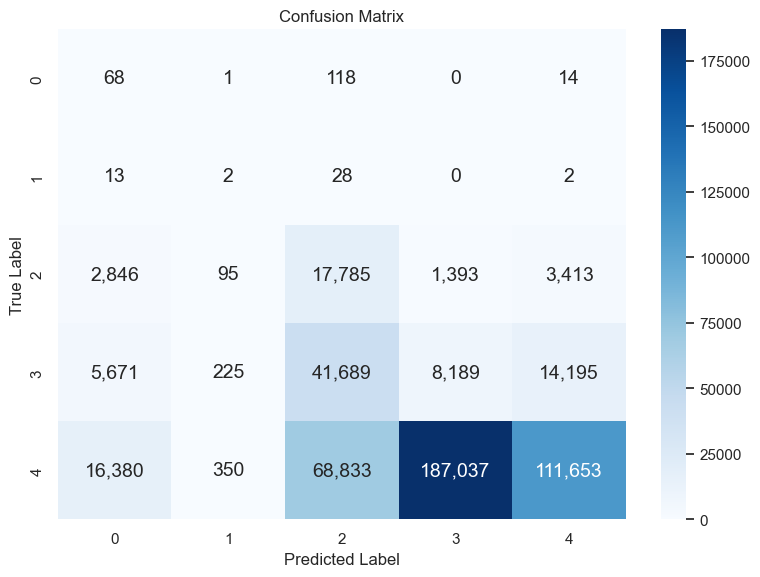

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 역변환
y_true_labels = SegmentEncoder.inverse_transform(y_train_encoded)
y_pred_labels = SegmentEncoder.inverse_transform(y_pred_train)

# 안전하게 라벨 추출
labels = list(np.unique(y_true_labels))

# 혼동 행렬
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

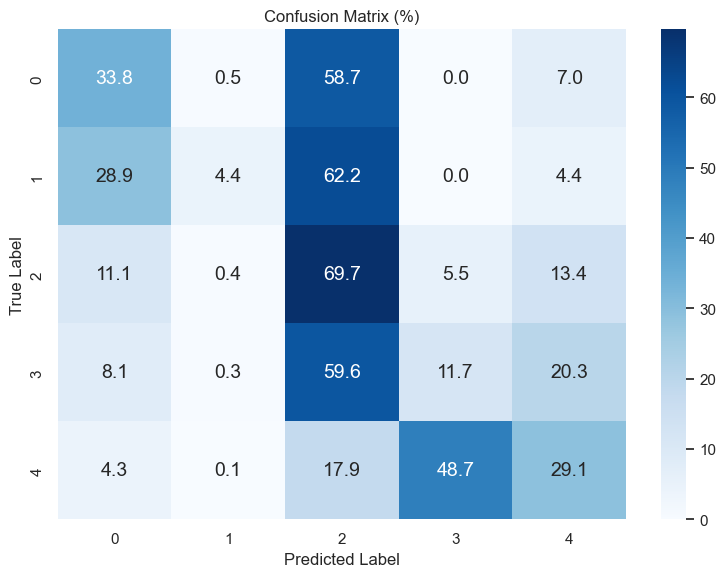

In [43]:
# 비율 기준 혼동행렬 계산
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

cm_percent_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent_df, annot=True, fmt=".1f", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (%)")
plt.tight_layout()
plt.show()
